In [1]:
"""
Prompt Chaining Gate (단계별 실행)

  outline 생성
  -> 검증
  -> 문서 생성

  [장점]
  정확도 증가

  [단점]
    latency 증가
"""

from typing import TypedDict, List
from langgraph.graph import StateGraph, START, END
from langchain.chat_models import init_chat_model
from pydantic import BaseModel

from langchain_google_vertexai import ChatVertexAI
import vertexai

vertexai.init(
    project="ai-prompt-evaluator-489612",
    location="us-central1",
)


llm = ChatVertexAI(
    model_name="gemini-2.5-flash-lite",
    max_tokens=500,
)

c:\my_study\workflow-architectures\.venv\Lib\site-packages\google\cloud\aiplatform\models.py:52: FutureWarning: Support for google-cloud-storage < 3.0.0 will be removed in a future version of google-cloud-aiplatform. Please upgrade to google-cloud-storage >= 3.0.0.
  from google.cloud.aiplatform.utils import gcs_utils


In [2]:
class State(TypedDict):
    dish: str
    ingredients: list[dict]
    recipe_steps: str
    plating_instructions: str


class Ingredient(BaseModel):
    name: str
    quantity: str
    unit: str


class IngredientsOutput(BaseModel):
    ingredients: List[Ingredient]


In [ ]:
def list_ingredients(state: State):
    # 1. 모델 응답을 바로 Pydantic(IngredientsOutput) 형태로 받도록 설정
    structured_llm = llm.with_structured_output(IngredientsOutput)
    response = structured_llm.invoke(
        f"List 5-8 ingredients needed to make {state['dish']}"
    )

    # 2. 간혹 구조화 파싱이 실패하면(None), Json 재요청으로 한 번 더 시도
    if response is None:
        fallback = llm.invoke(
            f"""
            Return ONLY valid JSON with this exact schema:
            {{
                "ingredients": [
                    {{
                        "name": "string",
                        "quantity": "string",
                        "unit": "string"
                    }}
                ]
            }}

            List 5-8 ingredients needed to make {state['dish']}.
            No markdown, no explanation.

            한글로 설명 부탁해요.
            """
        )

        # 3. 응답 본문(content)에서 JSON 객체 부분만 잘라서 파싱
        raw_text = fallback.content if hasattr(fallback, "content") else str(fallback)
        raw_text = raw_text.strip()
        json_start = raw_text.find("{")
        json_end = raw_text.rfind("}")

        if json_start == -1 or json_end == -1:
            raise ValueError("Could not parse JSON ingredients response from model")

        parsed = IngredientsOutput.model_validate_json(raw_text[json_start:json_end + 1])
        ingredients = parsed.Ingredients

    else:
        ingredients = response.ingredients

    # 4. Langraph state 타입에 맞게 Pydantic 객체 -> dict로 변환해서 반환
    return {
        "ingredients": [item.model_dump() for item in ingredients],
    }


def create_recipe(state: State):
    # 이전 노드(list_ingredients) 결과를 받아 레시피 단계 생성
    response = llm.invoke(
        f"""
        Write a step by step cooking instruction for {state['dish']}, using these ingredients {state['ingredients']}
        한글로 설명 부탁해요.
        """,
    )    

    return {
        "recipe_steps": response.content,
    }


def describe_plating(state: State):
    # 생성된 레시피를 바탕으로 플레이팅 (담는 방법) 설명 생성
    response = llm.invoke(
        f"""
        Describe how to beautifully plate this dish {state['dish']} based on this recipe {state['recipe_steps']}
        한글로 설명 부탁해요.
        """
    )

    return {
        "plating_instructions": response.content,
    }


def gate(state: State):
    ingredients = state["ingredients"]    

    if len(ingredients) > 8 or len(ingredients) < 3:
        return False

    return True

    

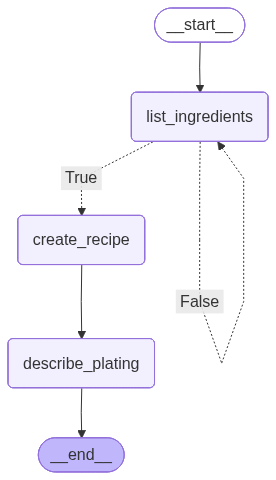

In [16]:
graph_builder = StateGraph(State)

graph_builder.add_node("list_ingredients", list_ingredients)
graph_builder.add_node("create_recipe", create_recipe)
graph_builder.add_node("describe_plating", describe_plating)

graph_builder.add_edge(START, "list_ingredients")
graph_builder.add_conditional_edges(
    "list_ingredients",
    gate,
    {
        True: "create_recipe",
        False: "list_ingredients",
    }
)
graph_builder.add_edge("create_recipe", "describe_plating")
graph_builder.add_edge("describe_plating", END)

graph = graph_builder.compile()

graph

In [21]:
from IPython.display import HTML, display, Markdown

def show_recipe_card(result):

    display(HTML("""
    <style>
    .recipe-card {
        border-radius: 15px;
        padding: 20px;
        background: #fafafa;
        box-shadow: 0px 4px 12px rgba(0,0,0,0.1);
        margin-bottom: 20px;
    }
    </style>
    """))

    display(HTML('<div class="recipe-card">'))

    dish = result.get("dish", "요리 이름 없음")
    ingredients = result.get("ingredients", [])
    recipe_steps = result.get("recipe_steps", "")
    plating = result.get("plating_instructions", "")

    display(Markdown(f"# 🍲 {dish} 레시피 카드"))

    ingredient_md = "## 🧂 재료 목록\n\n"
    for item in ingredients:
        ingredient_md += f'- {item["name"]}: {item["quantity"]} {item["unit"]}\n'

    display(Markdown(ingredient_md))

    display(Markdown("## 👩‍🍳 조리 방법"))
    display(Markdown(recipe_steps))

    display(Markdown("## 🍽️ 플레이팅 방법"))
    display(Markdown(plating))

    display(HTML("</div>"))

In [22]:
result = graph.invoke({
    "dish": "묵은지 두부",
})

show_recipe_card(result)

# 🍲 묵은지 두부 레시피 카드

## 🧂 재료 목록

- 묵은지 (aged kimchi): 1 head
- 두부 (tofu): 1 block
- pork belly: 0.5 pound
- onion: 1 medium
- green onions: 2 stalks
- garlic: 4 cloves
- red pepper flakes (gochugaru): 1 tablespoon
- soy sauce: 2 tablespoons


## 👩‍🍳 조리 방법

Here's a delicious recipe for 묵은지 두부 (Aged Kimchi and Tofu Stew), using the ingredients you provided:

**묵은지 두부 (Aged Kimchi and Tofu Stew)**

This savory and slightly spicy stew is a hearty and flavorful dish, perfect for a comforting meal. The aged kimchi provides a deep, complex flavor that pairs wonderfully with the soft tofu and rich pork belly.

**Yields:** 2-3 servings
**Prep time:** 15 minutes
**Cook time:** 30-40 minutes

**Ingredients:**

*   1 head 묵은지 (aged kimchi), roughly chopped (about 2-3 cups)
*   1 block 두부 (tofu), firm or medium-firm, cut into 1-inch cubes
*   0.5 pound pork belly, cut into bite-sized pieces
*   1 medium onion, sliced
*   2 stalks green onions, white and green parts separated, thinly sliced
*   4 cloves garlic, minced
*   1 tablespoon red pepper flakes (gochugaru)
*   2 tablespoons soy sauce
*   Water or anchovy broth (enough to cover ingredients, about 4-5 cups)
*   Optional: Pinch of sugar (if kimchi is very sour), salt to taste

**Equipment:**

*   Large pot or Dutch oven
*   Cutting board
*   Knife
*   Measuring spoons and cups

**Instructions:**

**Step 1: Prepare the Ingredients**

1.  **Aged Kimchi:** Take your head of 묵은지. If it's very large, you might not need the whole head. Roughly chop the kimchi leaves and stems into bite-sized pieces. Reserve some of the kimchi juice if you like a more intense flavor.
2.  **Tofu:** Carefully cut the block of tofu into 1-inch cubes.
3.  **Pork Belly:** Slice the pork belly into bite-sized pieces, about 1/2 inch thick.
4.  **Onion:** Peel and slice the medium onion.
5.  **Green Onions:** Wash the green onions. Separate the white and light green parts from the dark green tops. Thinly slice both parts.
6.  **Garlic:** Mince the garlic cloves.

**Step 2: Sauté the Pork

## 🍽️ 플레이팅 방법

## 묵은지 두부 맛있게 플레이팅하는 법 (한글)

묵은지 두부는 뚝배기나 냄비째 내놓는 것이 일반적이지만, 좀 더 정성스럽고 보기 좋게 플레이팅하고 싶다면 다음과 같은 방법들을 활용해 보세요.

**1. 기본 뚝배기/냄비 플레이팅:**

*   **가장 일반적이고 정통적인 방법:**
    *   잘 끓여진 묵은지 두부를 뚝배기나 냄비에 그대로 담아 뜨겁게 냅니다.
    *   **가니쉬 활용:**
        *   **송송 썬 대파 (흰 부분과 초록 부분 분리):** 뜨거운 뚝배기 위에 보기 좋게 흩뿌려주면 색감과 향이 더해집니다.
        *   **홍고추 또는 청양고추:** 얇게 썰어 몇 조각 올려주면 매콤함과 화려한 색감을 더할 수 있습니다.
        *   **통깨:** 마지막에 솔솔 뿌려주면 고소한 풍미와 함께 시각적인 완성도를 높여줍니다.
    *   **김치국물 활용:** 뚝배기 위에 김치국물을 살짝 둘러주면 촉촉함과 진한 맛을 강조할 수 있습니다.

**2. 개인 접시 플레이팅 (좀 더 정갈하게):**

*   **뚝배기나 냄비에서 덜어내 정갈하게 담기:**
    *   준비된 묵은지 두부를 깊이감이 있는 개인 접시에 보기 좋게 담습니다.
    *   **재료의 배치:**
        *   **두부:** 묵은지나 고기와 함께 섞이지 않도록 가장자리에 가지런히 놓거나, 큼직한 두부를 중앙에 배치합니다.
        *   **묵은지:** 뭉쳐있지 않도록 흐트러뜨려 자연스러운 볼륨감을 줍니다.
        *   **돼지고기:** 두부와 묵은지 사이에 보기 좋게 배치하거나,  위에 약간 얹어 줍니다.
    *   **국물 조절:** 국물이 너무 많지 않도록 적당량을 조절하여 접시에 담습니다. 너무